In [3]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('../data/raw/SPY_daily_yahoo_raw.csv', skiprows=[0,1,2], header=None, names=['Date','Adj Close','Close','High','Low','Open','Volume'], index_col=0, parse_dates=True, dtype={'Adj Close': float, 'Close': float, 'High': float, 'Low': float, 'Open': float, 'Volume': int})

# Compute 1-time-index linear increments
df['delta_P'] = df['Adj Close'].diff()

df = df.copy()
t = np.arange(1, len(df) + 1)

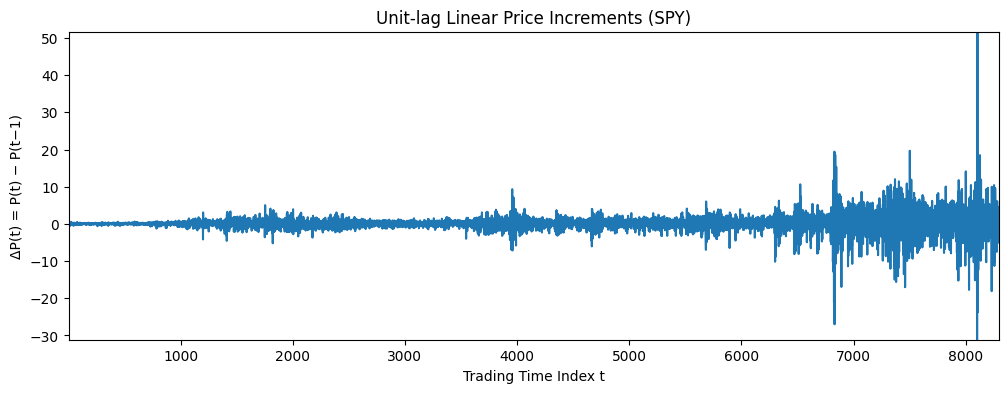

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(t, df['delta_P'])
plt.title('Unit-lag Linear Price Increments (SPY)')
plt.xlabel('Trading Time Index t')
plt.ylabel('ΔP(t) = P(t) − P(t−1)')
plt.xlim(min(t), max(t))
plt.ylim(np.nanmin(df['delta_P']), np.nanmax(df['delta_P']))
plt.show()


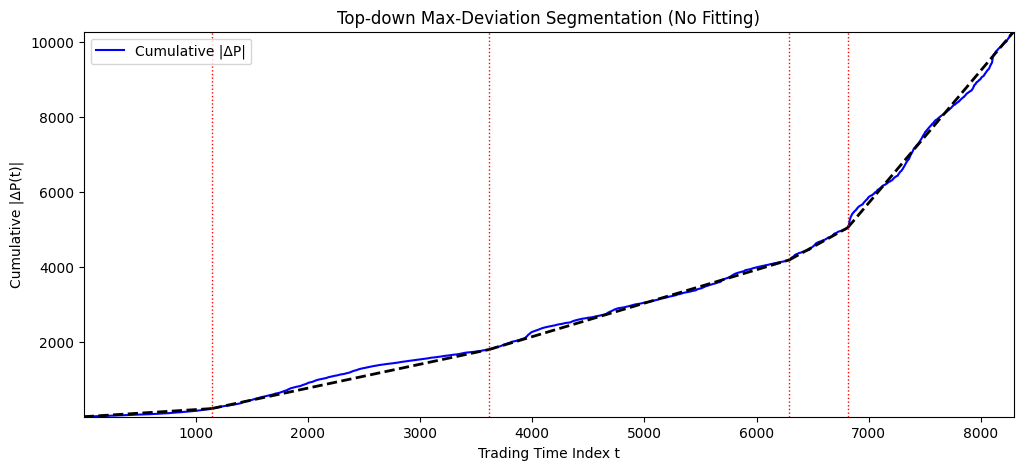

Segment 1: start=1, end=1143, slope=0.1902, N=1143
Segment 2: start=1143, end=3613, slope=0.6373, N=2471
Segment 3: start=3613, end=6293, slope=0.8934, N=2681
Segment 4: start=6293, end=6813, slope=1.6523, N=521
Segment 5: start=6813, end=8292, slope=3.5359, N=1480


In [5]:
# cumulative absolute increments
cum_abs = np.cumsum(np.abs(df['delta_P'].dropna().values))
t = np.arange(1, len(cum_abs)+1)  # start x-axis at 1

max_segments = 5  # keep number of breaks LOW

# initial segment
segments = [(0, len(cum_abs) - 1)]

while len(segments) < max_segments:
    max_err = -1
    best_split = None
    best_segment = None

    for start, end in segments:
        if end - start < 3:
            continue

        # straight line between endpoints (NO fitting)
        line = cum_abs[start] + (cum_abs[end] - cum_abs[start]) / (t[end] - t[start]) * (t[start:end+1] - t[start])
        err = np.abs(cum_abs[start:end+1] - line)

        idx = np.argmax(err)
        if err[idx] > max_err:
            max_err = err[idx]
            best_split = start + idx
            best_segment = (start, end)

    if best_segment is None:
        break

    segments.remove(best_segment)
    segments.append((best_segment[0], best_split))
    segments.append((best_split, best_segment[1]))

segments = sorted(segments, key=lambda x: x[0])

# ---------------- Plot ----------------
plt.figure(figsize=(12,5))
plt.plot(t, cum_abs, color='blue', label='Cumulative |ΔP|')

# plot straight segments
for start, end in segments:
    plt.plot(
        t[start:end+1],
        cum_abs[start] + (cum_abs[end] - cum_abs[start]) / (t[end] - t[start]) * (t[start:end+1] - t[start]),
        color='black',
        linestyle='dashed',
        linewidth=2
    )

# vertical break lines
for _, end in segments[:-1]:
    plt.axvline(t[end], color='red', linestyle='dotted', linewidth=1)  # use t[end] for correct x

plt.xlabel('Trading Time Index t')
plt.ylabel('Cumulative |ΔP(t)|')
plt.xlim(min(t), max(t))
plt.ylim(np.nanmin(cum_abs), np.nanmax(cum_abs))
plt.title('Top-down Max-Deviation Segmentation (No Fitting)')
plt.legend()
plt.show()

# segment summary
for i, (start, end) in enumerate(segments):
    slope = (cum_abs[end] - cum_abs[start]) / (t[end] - t[start])
    print(f"Segment {i+1}: start={t[start]}, end={t[end]}, slope={slope:.4f}, N={end-start+1}")


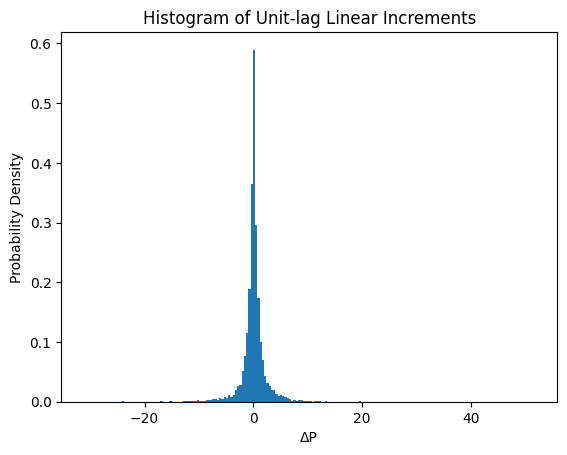

In [6]:
plt.figure()
plt.hist(df['delta_P'].dropna(), bins=200, density=True)
plt.title('Histogram of Unit-lag Linear Increments')
plt.xlabel('ΔP')
plt.ylabel('Probability Density')
plt.show()
# Plot the linear increments

In [ ]:
################################################################################

In [60]:
def conditional_exceedance_percentile_fixed(P, tau, q_percentile, direction='+', r_percentiles=None):
    """
    Compute raw conditional exceedance probabilities for multiple future thresholds r_percentiles.
    q_percentile: conditioning threshold percentile
    r_percentiles: list of future exceedance percentiles (0-1)
    direction: '+' or '-' (past increment sign)
    """
    dP = increments(P, tau)
    past = dP[:-tau]
    future = dP[tau:]
    
    # Determine past threshold for conditioning
    if direction == '+':
        q_thresh = np.quantile(past, q_percentile)
        condition = past >= q_thresh
    else:
        q_thresh = np.quantile(past, 1 - q_percentile)
        condition = past <= q_thresh

    if condition.sum() == 0:
        return r_percentiles, np.full(len(r_percentiles), np.nan)
    
    probs = []
    # Compute raw exceedance probabilities for all r_percentiles using **all future increments**
    for r_pct in r_percentiles:
        if direction == '+':
            r_thresh = np.quantile(future, r_pct)  # from ALL future increments
            exceed = future[condition] >= r_thresh
        else:
            r_thresh = np.quantile(future, 1 - r_pct)
            exceed = future[condition] <= r_thresh
        probs.append(exceed.mean())
    
    return r_percentiles, np.array(probs)


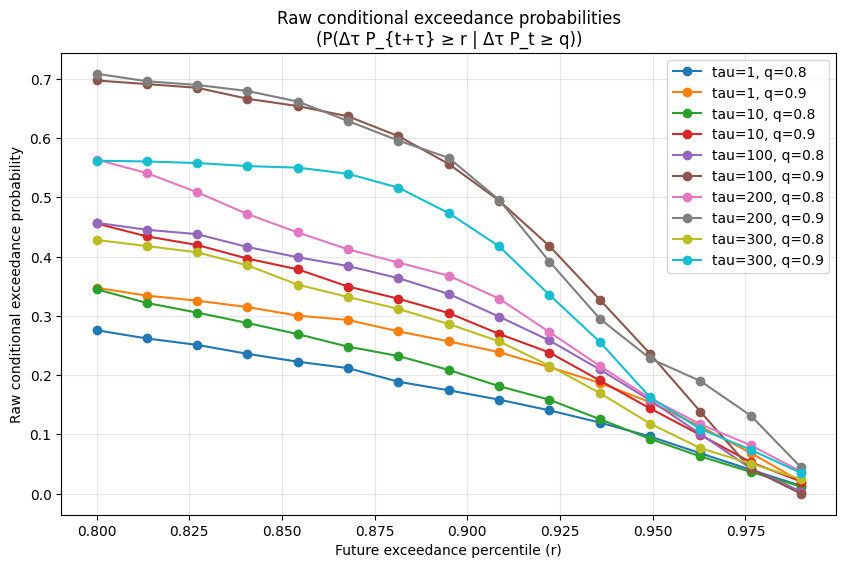

In [63]:
taus = [1,10,100,200,300]
q_percentiles = [0.8, 0.9]
r_percentiles = np.linspace(0.8, 0.99, 15)  # future exceedance percentiles

plt.figure(figsize=(10,6))

for tau in taus:
    for q in q_percentiles:
        r, prob = conditional_exceedance_percentile_fixed(
            P, tau, q_percentile=q, direction='+', r_percentiles=r_percentiles
        )
        plt.plot(r, prob, marker='o', linestyle='-', 
                 label=f'tau={tau}, q={q}')

plt.xlabel('Future exceedance percentile (r)')
plt.ylabel('Raw conditional exceedance probability')
plt.title('Raw conditional exceedance probabilities\n(P(Δτ P_{t+τ} ≥ r | Δτ P_t ≥ q))')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


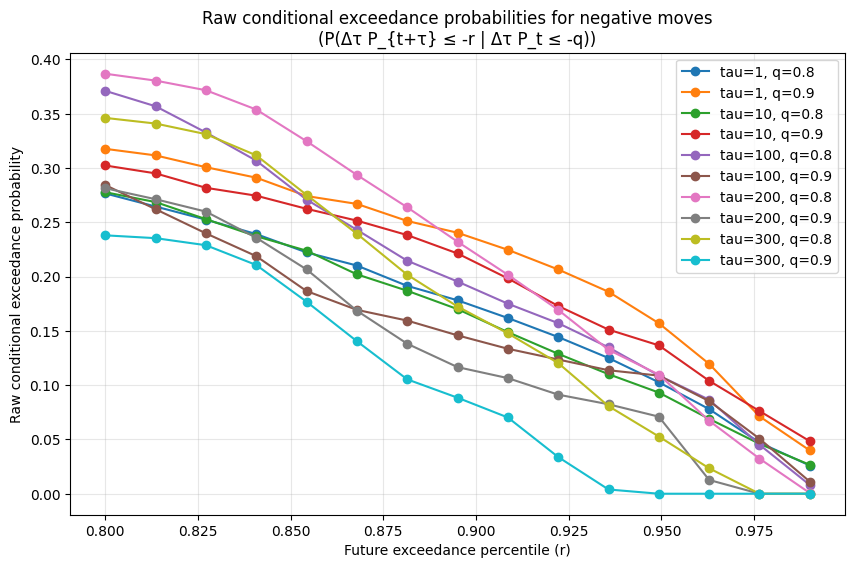

In [64]:
taus = [1, 10, 100, 200, 300]
q_percentiles = [0.8, 0.9]  # for conditioning, but direction '-' uses lower tail
r_percentiles = np.linspace(0.8, 0.99, 15)  # future exceedance percentiles

plt.figure(figsize=(10,6))

for tau in taus:
    for q in q_percentiles:
        r, prob = conditional_exceedance_percentile_fixed(
            P, tau, q_percentile=q, direction='-', r_percentiles=r_percentiles
        )
        plt.plot(r, prob, marker='o', linestyle='-', 
                 label=f'tau={tau}, q={q}')

plt.xlabel('Future exceedance percentile (r)')
plt.ylabel('Raw conditional exceedance probability')
plt.title('Raw conditional exceedance probabilities for negative moves\n(P(Δτ P_{t+τ} ≤ -r | Δτ P_t ≤ -q))')
plt.grid(alpha=0.3)
plt.legend()
plt.show()
